In [176]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm


In [177]:
# References
# https://datatas.com/how-to-use-variational-autoencoders-for-large-scale-data-compression/

In [178]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25

In [179]:
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_encoded_patch_bits(encoded_size,
                           patch_size,
                           module_rows=160,
                           module_cols=416):
    
    encoded_width, encoded_height, num_embeddings = encoded_size
    # print(encoded_width, encoded_height, np.log2(num_embeddings))
    vq_bits = encoded_width * encoded_height * np.log2(num_embeddings)
    
    # Patch address bits
    bits_patch_row = np.ceil(np.log2(np.ceil(module_rows / patch_size)))
    bits_patch_col = np.ceil(np.log2(np.ceil(module_cols / patch_size)))
    total = bits_patch_row + bits_patch_col + vq_bits
    
    # 267 % 256 = 11
    return total.astype(np.uint8)

def _get_total_hit_bits(total_hits: int) -> int:
    
    # Patch address bits
    return total_hits * BITS_HIT

def _get_total_patch_bits(patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> int:
    encoded_patch_bits = _get_encoded_patch_bits(encoded_patch_size, patch_size)
    return np.uint64(patch_amount) * encoded_patch_bits

# TODO: test the method
def _get_compression_ratio(n_hits_total: int, patch_amount: int, encoded_patch_size: tuple, patch_size: int) -> float:
    
    total_bits = _get_total_hit_bits(n_hits_total)
    total_patch_bits = _get_total_patch_bits(
        patch_amount, 
        encoded_patch_size, 
        patch_size
    )
    return total_bits / total_patch_bits

def _get_patch_count(event: PixelDigiEvent) -> int:
    event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
    event_patches_adcs = [
        event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
        for event_patch_flat in event_patches_adcs_flat
    ]
    return len(event_patches_adcs)

    
# helper function
def _display_gradients(model: object) -> None:
    print("Showing model gradients")
    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.norm().item())
            
def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()

In [180]:
# Loading data

pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 226.17it/s]


In [181]:
batch_size = 64
beta = 0
learning_rate = 1e-2
num_epochs = 120
channels = 1
latent_dim = 64

# Comment:
# Need to use bigger latent dimension. Bigger than 16. Wider latent dimension,
# the more information is preserved after matrix transformations
# If latent dimension = 16, than noisy outputs from encoder

# num_embeddings = 256 
LOG_EVERY = 10


In [182]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [183]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [184]:
event_train = events_train[:SELECTED_EVENTS][0]

In [185]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
        ]
        
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [186]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0], std=[1])    
])

event_dataset = PixelPatchesDataset(event_train, transform)

# Training data prepearation
train_loader = DataLoader(
    dataset=event_dataset, 
    batch_size=batch_size
)

# Test data preparation
# TODO: apply after the training examples are good
events_test_loaders = []
for event_test in events_test:
    event_dataset = PixelPatchesDataset(event_test, transform)

    event_test_loader = DataLoader(
        dataset=event_dataset, 
        batch_size=batch_size
    )
    events_test_loaders.append(event_test_loader)

In [187]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor, 
    mu: torch.tensor, 
    logvar: torch.tensor
) -> float:
    # recon_loss = F.mse_loss(
    #     recon_x, 
    #     x, 
    #     reduction="sum"
    # ) / x.size(0)
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="sum")
    
    # KL_divergence
    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )
    
    return (
        recon_loss + beta * kl_loss,
        recon_loss,
        beta,
        kl_loss
    )

In [188]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, hidden_channels * 2, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.LeakyReLU(slope),
        )
        # self.flatten = nn.Flatten()
        self.fc_mean = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        self.fc_log_var = nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=1)
        # self.fc_mean = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )
        torch.nn.init.xavier_uniform_(self.fc_mean.weight)
        
        # self.fc_log_var = nn.Linear(
        #     hidden_channels * 2 * PATCH_SIZE//4 * PATCH_SIZE//4, 
        #     latent_dim * 4
        # )        
        torch.nn.init.xavier_uniform_(self.fc_log_var.weight)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        
        
    def forward(self, x):
        # apply convolutional layers with relu activation function
        # print("x range:", x.min().item(), x.max().item())
        
        x_encoded = self.encoder(x)
        
        # x_flatten = self.flatten(x_encoded)
        
        # get the mean and log variance of the latent space distribution
        z_log_mean = self.fc_mean(x_encoded)
        z_log_var = self.fc_log_var(x_encoded)
        
        self.z_log_mean = torch.clamp(z_log_mean, min=-10, max=10)
        self.z_log_var = torch.clamp(z_log_var, min=-4, max=1)
        
        # sample a latent vector using the reparameterization trick
        
        z = self.reparameterize(self.z_log_mean, self.z_log_var)
        
        output = self.decoder(z)
        
        return output, self.z_log_mean, self.z_log_var

In [189]:
model = VAE(
    hidden_channels=32, 
    kernel_size = 4,
    slope=0.01
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/120: 100%|██████████| 248/248 [00:00<00:00, 693.07it/s, Loss=117] 


Epoch [1/120] Average Loss: 260.3629
Before compression
Before: (64, 8, 8)


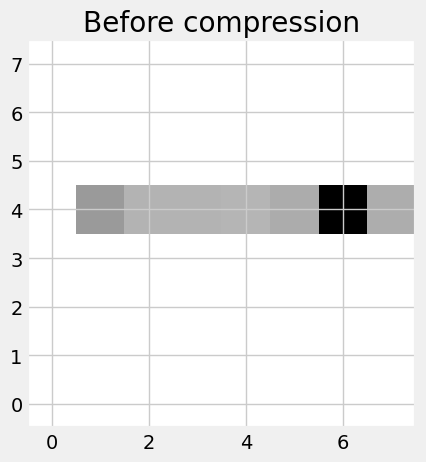

mu: mean=-0.0682, std=0.8808 | logvar: mean=-2.7478, std=1.0652
Loss statistics:

After: (1, 8, 8)
After compression


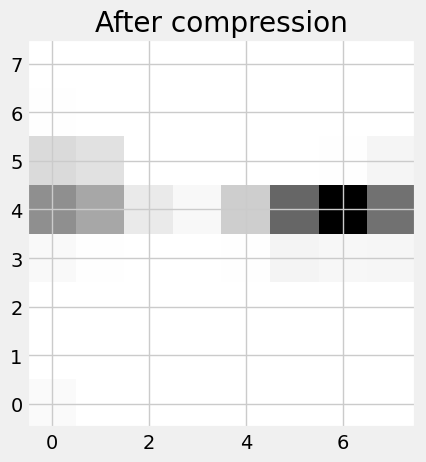

Epoch 2/120: 100%|██████████| 248/248 [00:00<00:00, 678.07it/s, Loss=101] 


Epoch [2/120] Average Loss: 144.6587


Epoch 3/120: 100%|██████████| 248/248 [00:00<00:00, 682.02it/s, Loss=99.6]


Epoch [3/120] Average Loss: 131.8944


Epoch 4/120: 100%|██████████| 248/248 [00:00<00:00, 668.48it/s, Loss=95.5]


...

Epoch [9/120] Average Loss: 120.0392


Epoch 10/120: 100%|██████████| 248/248 [00:00<00:00, 666.43it/s, Loss=91.2]


Epoch [10/120] Average Loss: 119.8179


Epoch 11/120: 100%|██████████| 248/248 [00:00<00:00, 674.34it/s, Loss=91.3]


Epoch [11/120] Average Loss: 119.3275
Before compression
Before: (64, 8, 8)


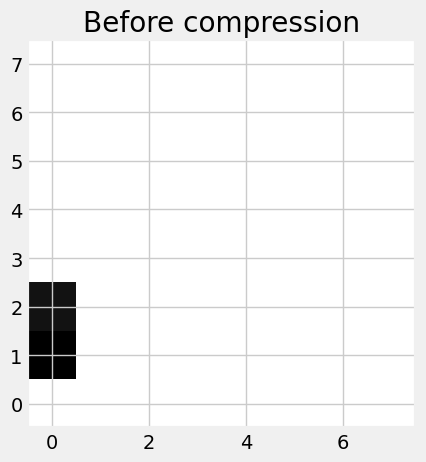

mu: mean=-0.0648, std=0.8117 | logvar: mean=-3.9243, std=0.2603
Loss statistics:

After: (1, 8, 8)
After compression


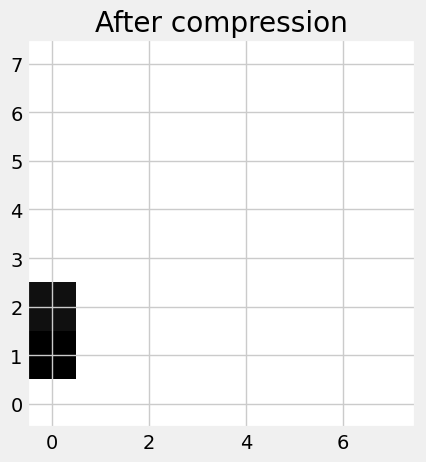

Epoch 12/120: 100%|██████████| 248/248 [00:00<00:00, 661.71it/s, Loss=92.9]


Epoch [12/120] Average Loss: 118.8376


Epoch 13/120: 100%|██████████| 248/248 [00:00<00:00, 673.03it/s, Loss=90.5]


Epoch [13/120] Average Loss: 118.6941


Epoch 14/120: 100%|██████████| 248/248 [00:00<00:00, 667.81it/s, Loss=93]  


...

Epoch [19/120] Average Loss: 115.4409


Epoch 20/120: 100%|██████████| 248/248 [00:00<00:00, 675.93it/s, Loss=90.4]


Epoch [20/120] Average Loss: 115.3583


Epoch 21/120: 100%|██████████| 248/248 [00:00<00:00, 681.45it/s, Loss=92.4]


Epoch [21/120] Average Loss: 115.2719
Before compression
Before: (64, 8, 8)


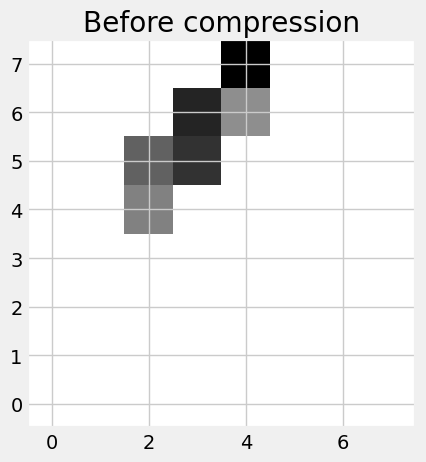

mu: mean=-0.0604, std=0.8932 | logvar: mean=-3.9237, std=0.2773
Loss statistics:

After: (1, 8, 8)
After compression


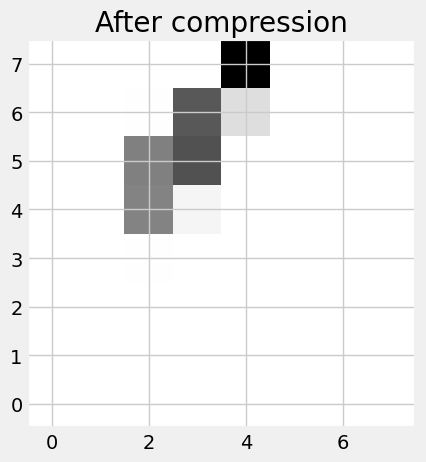

Epoch 22/120: 100%|██████████| 248/248 [00:00<00:00, 691.19it/s, Loss=91.3]


Epoch [22/120] Average Loss: 114.8972


Epoch 23/120: 100%|██████████| 248/248 [00:00<00:00, 699.62it/s, Loss=91.6]


Epoch [23/120] Average Loss: 114.3296


Epoch 24/120: 100%|██████████| 248/248 [00:00<00:00, 695.86it/s, Loss=88]  


...

Epoch [29/120] Average Loss: 112.5675


Epoch 30/120: 100%|██████████| 248/248 [00:00<00:00, 670.28it/s, Loss=88.7]


Epoch [30/120] Average Loss: 112.5059


Epoch 31/120: 100%|██████████| 248/248 [00:00<00:00, 663.41it/s, Loss=87.9]


Epoch [31/120] Average Loss: 111.6914
Before compression
Before: (64, 8, 8)


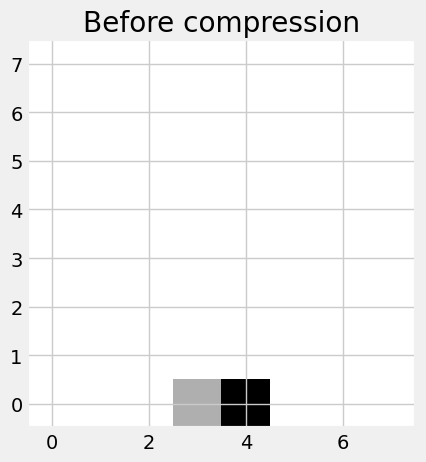

mu: mean=-0.0798, std=0.8124 | logvar: mean=-3.9564, std=0.1855
Loss statistics:

After: (1, 8, 8)
After compression


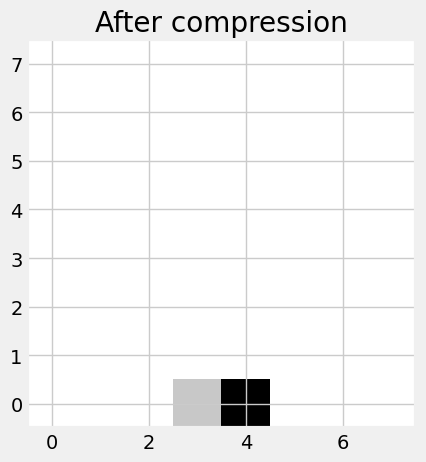

Epoch 32/120: 100%|██████████| 248/248 [00:00<00:00, 662.36it/s, Loss=87.9]


Epoch [32/120] Average Loss: 111.8645


Epoch 33/120: 100%|██████████| 248/248 [00:00<00:00, 666.32it/s, Loss=89.4]


Epoch [33/120] Average Loss: 111.3928


Epoch 34/120: 100%|██████████| 248/248 [00:00<00:00, 669.12it/s, Loss=87.7]


...

Epoch [39/120] Average Loss: 110.7572


Epoch 40/120: 100%|██████████| 248/248 [00:00<00:00, 670.96it/s, Loss=87.6]


Epoch [40/120] Average Loss: 110.6706


Epoch 41/120: 100%|██████████| 248/248 [00:00<00:00, 679.71it/s, Loss=87.9]


Epoch [41/120] Average Loss: 110.3584
Before compression
Before: (64, 8, 8)


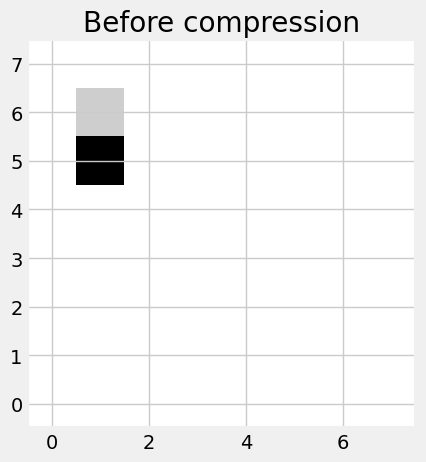

mu: mean=-0.0594, std=0.9653 | logvar: mean=-3.9658, std=0.1826
Loss statistics:

After: (1, 8, 8)
After compression


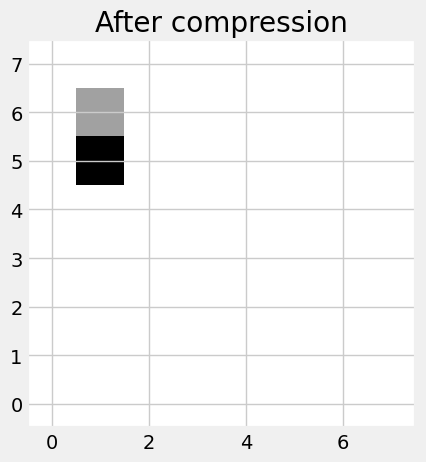

Epoch 42/120: 100%|██████████| 248/248 [00:00<00:00, 676.46it/s, Loss=88]  


Epoch [42/120] Average Loss: 111.0363


Epoch 43/120: 100%|██████████| 248/248 [00:00<00:00, 670.88it/s, Loss=87.2]


Epoch [43/120] Average Loss: 110.3144


Epoch 44/120: 100%|██████████| 248/248 [00:00<00:00, 666.63it/s, Loss=89.4]


...

Epoch [49/120] Average Loss: 109.3347


Epoch 50/120: 100%|██████████| 248/248 [00:00<00:00, 680.15it/s, Loss=87.1]


Epoch [50/120] Average Loss: 109.9403


Epoch 51/120: 100%|██████████| 248/248 [00:00<00:00, 662.18it/s, Loss=87.2]


Epoch [51/120] Average Loss: 109.6577
Before compression
Before: (64, 8, 8)


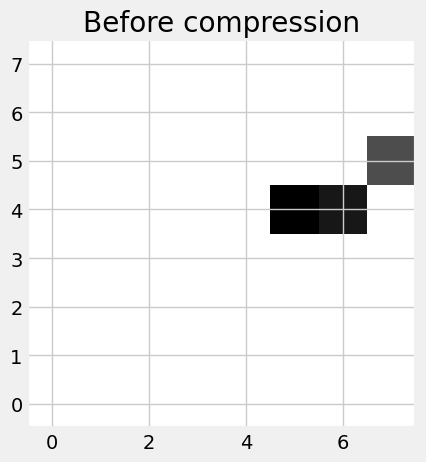

mu: mean=-0.0797, std=0.9077 | logvar: mean=-3.9518, std=0.1907
Loss statistics:

After: (1, 8, 8)
After compression


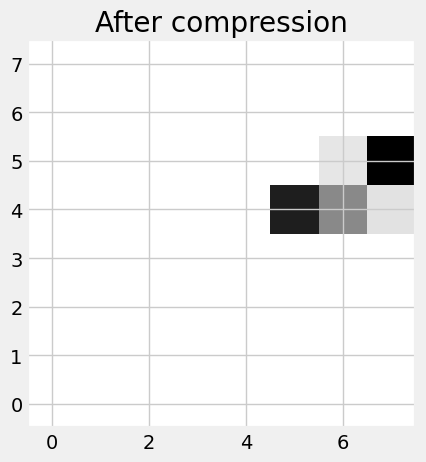

Epoch 52/120: 100%|██████████| 248/248 [00:00<00:00, 661.49it/s, Loss=88.7]


Epoch [52/120] Average Loss: 109.7550


Epoch 53/120: 100%|██████████| 248/248 [00:00<00:00, 698.80it/s, Loss=86.8]


Epoch [53/120] Average Loss: 109.3341


Epoch 54/120: 100%|██████████| 248/248 [00:00<00:00, 693.64it/s, Loss=88.4]


...

Epoch [59/120] Average Loss: 109.1361


Epoch 60/120: 100%|██████████| 248/248 [00:00<00:00, 672.90it/s, Loss=86.5]


Epoch [60/120] Average Loss: 109.3474


Epoch 61/120: 100%|██████████| 248/248 [00:00<00:00, 672.08it/s, Loss=88]  


Epoch [61/120] Average Loss: 109.7366
Before compression
Before: (64, 8, 8)


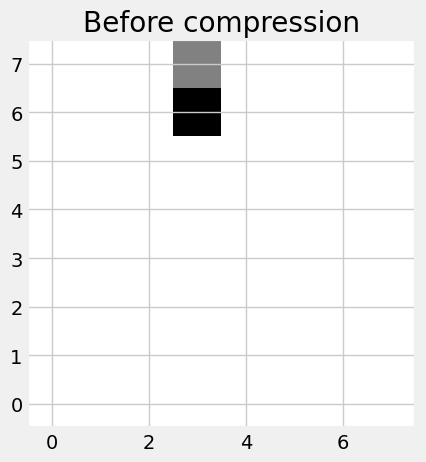

mu: mean=-0.1039, std=0.8237 | logvar: mean=-3.9638, std=0.1754
Loss statistics:

After: (1, 8, 8)
After compression


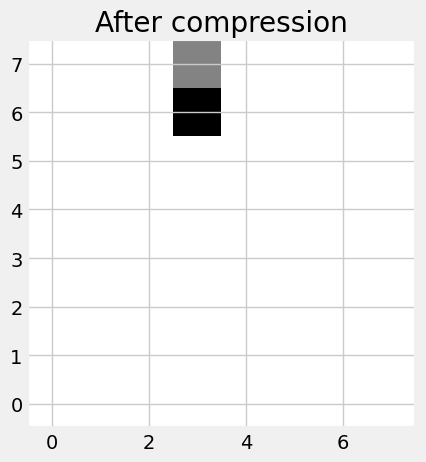

Epoch 62/120: 100%|██████████| 248/248 [00:00<00:00, 669.11it/s, Loss=86.2]


Epoch [62/120] Average Loss: 108.7398


Epoch 63/120: 100%|██████████| 248/248 [00:00<00:00, 692.22it/s, Loss=87.2]


Epoch [63/120] Average Loss: 108.8773


Epoch 64/120: 100%|██████████| 248/248 [00:00<00:00, 693.27it/s, Loss=88.4]


...

Epoch [69/120] Average Loss: 108.8577


Epoch 70/120: 100%|██████████| 248/248 [00:00<00:00, 685.51it/s, Loss=86.7]


Epoch [70/120] Average Loss: 108.6011


Epoch 71/120: 100%|██████████| 248/248 [00:00<00:00, 687.50it/s, Loss=86.4]


Epoch [71/120] Average Loss: 108.5015
Before compression
Before: (64, 8, 8)


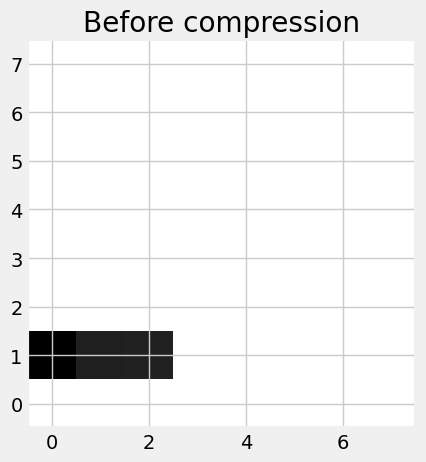

mu: mean=-0.0732, std=0.7903 | logvar: mean=-3.9350, std=0.2451
Loss statistics:

After: (1, 8, 8)
After compression


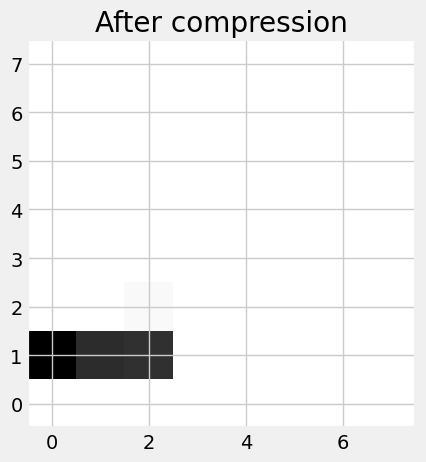

Epoch 72/120: 100%|██████████| 248/248 [00:00<00:00, 694.71it/s, Loss=86.7]


Epoch [72/120] Average Loss: 108.8119


Epoch 73/120: 100%|██████████| 248/248 [00:00<00:00, 697.53it/s, Loss=86]  


Epoch [73/120] Average Loss: 108.3059


Epoch 74/120: 100%|██████████| 248/248 [00:00<00:00, 695.26it/s, Loss=86.3]


...

Epoch [79/120] Average Loss: 108.6118


Epoch 80/120: 100%|██████████| 248/248 [00:00<00:00, 692.37it/s, Loss=86.5]


Epoch [80/120] Average Loss: 108.2854


Epoch 81/120: 100%|██████████| 248/248 [00:00<00:00, 655.41it/s, Loss=87.1]


Epoch [81/120] Average Loss: 108.4758
Before compression
Before: (64, 8, 8)


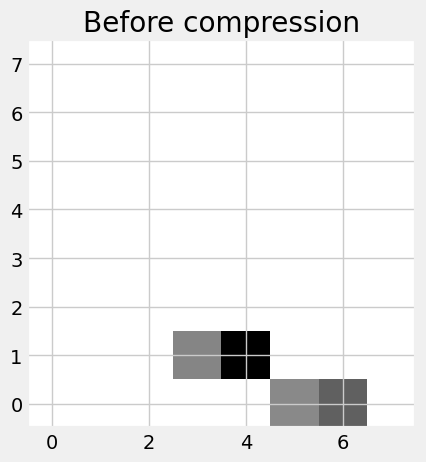

mu: mean=-0.0592, std=0.8991 | logvar: mean=-3.9737, std=0.1339
Loss statistics:

After: (1, 8, 8)
After compression


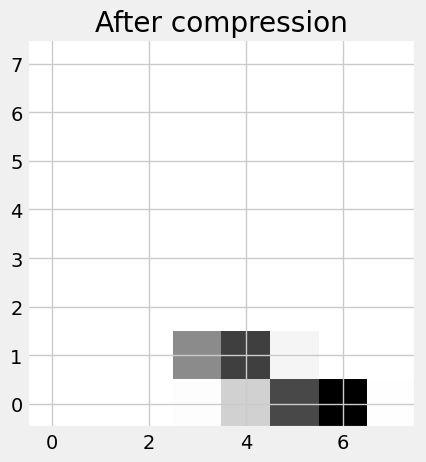

Epoch 82/120: 100%|██████████| 248/248 [00:00<00:00, 694.76it/s, Loss=86.5]


Epoch [82/120] Average Loss: 108.2922


Epoch 83/120: 100%|██████████| 248/248 [00:00<00:00, 694.65it/s, Loss=86.6]


Epoch [83/120] Average Loss: 108.1036


Epoch 84/120: 100%|██████████| 248/248 [00:00<00:00, 665.16it/s, Loss=86.7]


...

Epoch [89/120] Average Loss: 107.9816


Epoch 90/120: 100%|██████████| 248/248 [00:00<00:00, 673.52it/s, Loss=86.6]


Epoch [90/120] Average Loss: 108.0745


Epoch 91/120: 100%|██████████| 248/248 [00:00<00:00, 666.15it/s, Loss=86.2]


Epoch [91/120] Average Loss: 107.9054
Before compression
Before: (64, 8, 8)


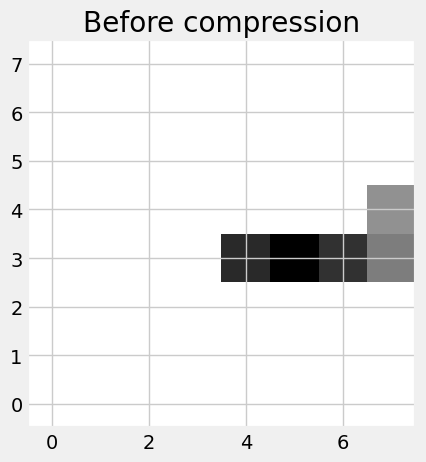

mu: mean=-0.0653, std=0.9248 | logvar: mean=-3.9660, std=0.1670
Loss statistics:

After: (1, 8, 8)
After compression


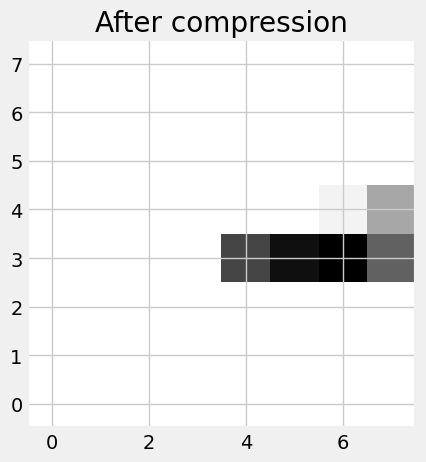

Epoch 92/120: 100%|██████████| 248/248 [00:00<00:00, 674.14it/s, Loss=86.1]


Epoch [92/120] Average Loss: 108.1719


Epoch 93/120: 100%|██████████| 248/248 [00:00<00:00, 693.60it/s, Loss=86.4]


Epoch [93/120] Average Loss: 107.8729


Epoch 94/120: 100%|██████████| 248/248 [00:00<00:00, 666.12it/s, Loss=85.9]


...

Epoch [99/120] Average Loss: 107.5806


Epoch 100/120: 100%|██████████| 248/248 [00:00<00:00, 662.46it/s, Loss=86]  


Epoch [100/120] Average Loss: 107.7907


Epoch 101/120: 100%|██████████| 248/248 [00:00<00:00, 661.01it/s, Loss=85.3]


Epoch [101/120] Average Loss: 107.6256
Before compression
Before: (64, 8, 8)


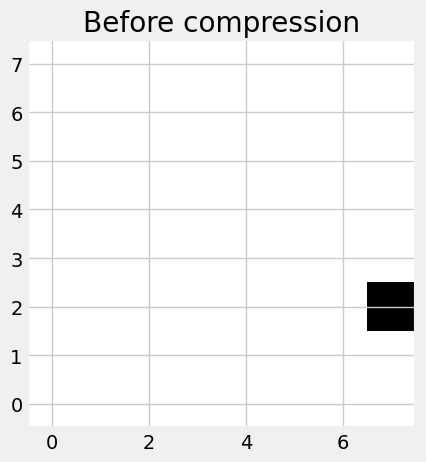

mu: mean=-0.0753, std=0.8143 | logvar: mean=-3.9695, std=0.1465
Loss statistics:

After: (1, 8, 8)
After compression


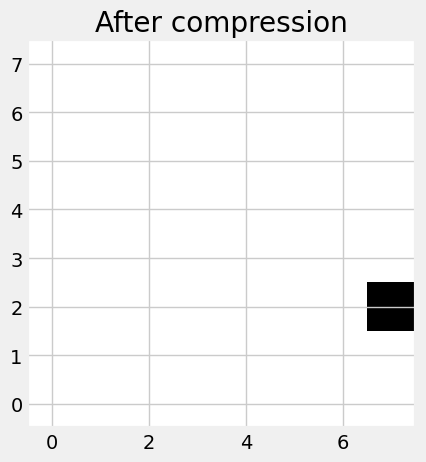

Epoch 102/120: 100%|██████████| 248/248 [00:00<00:00, 663.78it/s, Loss=85.9]


Epoch [102/120] Average Loss: 107.6744


Epoch 103/120: 100%|██████████| 248/248 [00:00<00:00, 674.03it/s, Loss=86]  


Epoch [103/120] Average Loss: 107.8873


Epoch 104/120: 100%|██████████| 248/248 [00:00<00:00, 686.24it/s, Loss=85.8]


...

Epoch [109/120] Average Loss: 107.4895


Epoch 110/120: 100%|██████████| 248/248 [00:00<00:00, 672.24it/s, Loss=85.7]


Epoch [110/120] Average Loss: 107.2761


Epoch 111/120: 100%|██████████| 248/248 [00:00<00:00, 670.65it/s, Loss=87.1]


Epoch [111/120] Average Loss: 108.0383
Before compression
Before: (64, 8, 8)


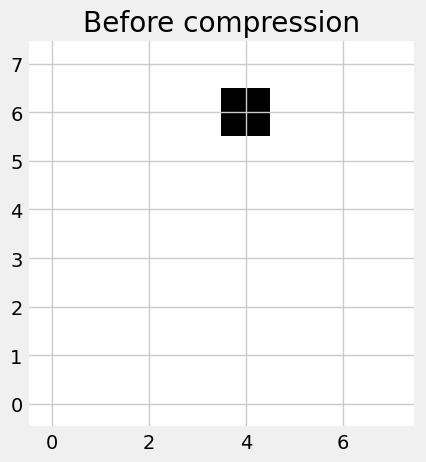

mu: mean=-0.0570, std=0.7564 | logvar: mean=-3.9614, std=0.1643
Loss statistics:

After: (1, 8, 8)
After compression


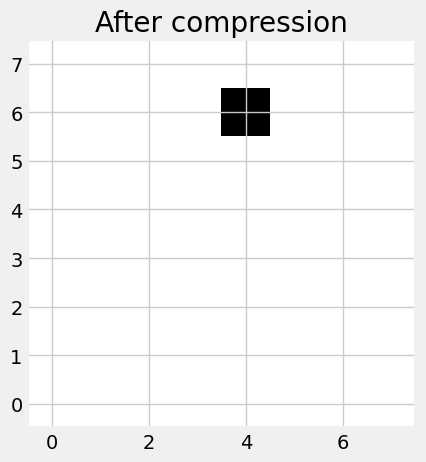

Epoch 112/120: 100%|██████████| 248/248 [00:00<00:00, 676.17it/s, Loss=86.8]


Epoch [112/120] Average Loss: 107.5235


Epoch 113/120: 100%|██████████| 248/248 [00:00<00:00, 696.84it/s, Loss=86.2]


Epoch [113/120] Average Loss: 107.2618


Epoch 114/120: 100%|██████████| 248/248 [00:00<00:00, 666.39it/s, Loss=85.7]


...

Epoch [118/120] Average Loss: 107.2131


Epoch 119/120: 100%|██████████| 248/248 [00:00<00:00, 656.58it/s, Loss=86.2]


Epoch [119/120] Average Loss: 107.3652


Epoch 120/120: 100%|██████████| 248/248 [00:00<00:00, 655.96it/s, Loss=85.2]

Epoch [120/120] Average Loss: 107.8463


In [190]:
average_loss = []
patches_before = []
patches_after = []

patch_test_cursor = iter(events_test_loaders[0])
model.train()

for epoch in range(num_epochs):
    train_loss = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        
        # Adding some randomness for regulating the small noisy areas
        # X_adcs = X_adcs + 0.01 * torch.randn_like(X_adcs)
        
        X_adcs = X_adcs.to(device)
        
    
        (
            recon_patch, 
            mu,
            logvar 
        ) = model(
           X_adcs
        )
        
        loss, recon_loss, beta, kl_loss = _get_vae_loss(recon_patch, X_adcs, mu, logvar)
        
        recon_patch = recon_patch.float().to(device)      
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        
        train_loss += loss.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
        
        
    # Saving epoch  statistics
    
    avg_loss = train_loss / len(train_loader)
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
    average_loss.append(avg_loss)
    
    if epoch % LOG_EVERY == 0:
        with torch.no_grad():            
            # selecting events before reconstruction using one test loader as validation
            patch_test = next(patch_test_cursor) 
            patch_test = patch_test.to(device)           
            print("Before compression")
            
            patch_test_ts = _tensor_to_numpy(
                patch_test.squeeze(1)
            )
            
            print(f"Before: {patch_test_ts.shape}")            
            plot_patch(patch_test_ts[0], "Before compression")
            
            patches_before.append(patch_test_ts[0])
            
            (
                recon_patch, 
                mu,
                logvar 
            ) = model(patch_test)
            
            print(
                f"mu: mean={mu.mean().item():.4f}, std={mu.std().item():.4f} | "
                f"logvar: mean={logvar.mean().item():.4f}, std={logvar.std().item():.4f}"
            )
            
            print("Loss statistics:")
            print(
                f"recon={recon_loss.item():.4f}, "
                f"kl={kl_loss.item():.4f}, " if beta > 0 else ""
                f"beta_kl={(beta * kl_loss).item():.4f}" if beta > 0 else ""
            )
            
            recon_patch_np = _tensor_to_numpy(
                recon_patch[0]
            )
            print(f"After: {recon_patch_np.shape}")
            print("After compression")
            
            plot_patch(recon_patch_np[0], "After compression")
            
            patches_after.append(recon_patch_np[0])
        

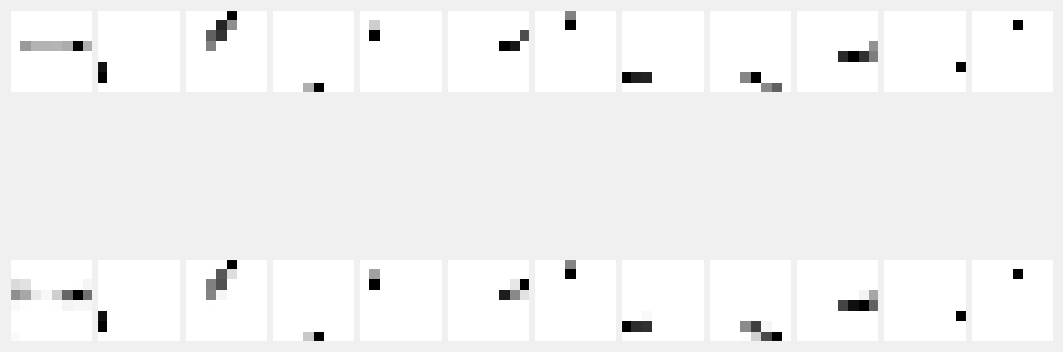

In [191]:
image_rows = [
    patches_before,
    patches_after
]
cols = len(image_rows[0])
rows = len(image_rows)

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i in range(rows):
    for j in range(cols):
        ax = axes[i, j]
        ax.imshow(image_rows[i][j], cmap='gist_yarg', origin='lower')
        
        ax.set_xticks([])
        ax.set_yticks([])
        
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.5)

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

In [192]:
# TODO
# Improve gradients
_display_gradients(model)

Showing model gradients
encoder.0.weight 0.6943889856338501
encoder.2.weight 0.18723918497562408
encoder.4.weight 0.20680132508277893
fc_mean.weight 0.5054988265037537
fc_mean.bias 0.1408243179321289
fc_log_var.weight 0.0008912557386793196
fc_log_var.bias 0.0011838366044685245
decoder.0.weight 0.2783995270729065
decoder.2.weight 0.31285303831100464
decoder.4.weight 4.897881984710693


/tmp/ipykernel_2970954/1764288248.py:81: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


VAE, Average loss values over epochs


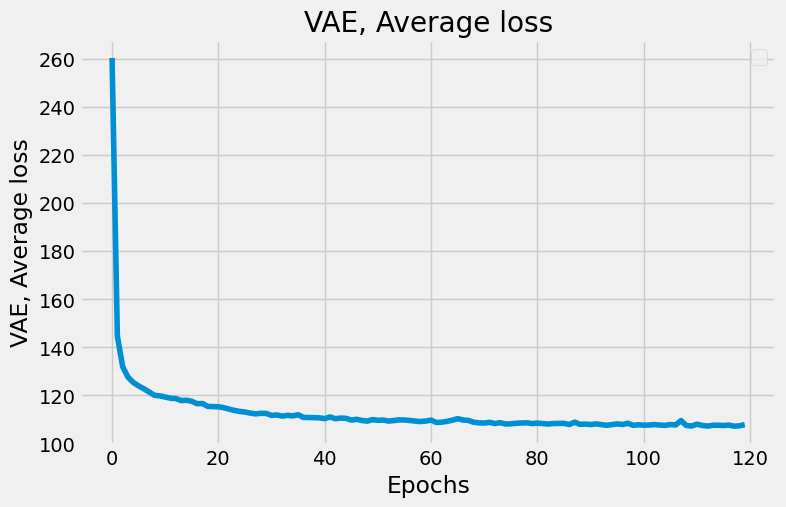

In [193]:
# display loss values
plot_metric_results(
    y_values=average_loss, 
    x_values=list(range(num_epochs)),
    y_title="VAE, Average loss",
    title="VAE, Average loss",
    x_label="Epochs"
)

In [194]:
print(f"mu = {model.z_log_mean.mean().item()}")
print(f"logvar = {model.z_log_var.std().item()}")

mu = -0.08330351114273071
logvar = 0.13821302354335785
